In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv(r'/Users/anirudhiyer/Desktop/Stress Prediction/Minor-Project/Datasets/Final_processed.csv')

In [6]:
df.head()

,Unnamed: 0,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,2,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,3,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,4,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,1
4,5,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 38 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   360 non-null    int64  
 1   Age          360 non-null    int64  
 2   Q1           360 non-null    float64
 3   Q2           360 non-null    float64
 4   Q3           360 non-null    float64
 5   Q4           360 non-null    float64
 6   Q5           360 non-null    float64
 7   Q6           360 non-null    float64
 8   Q7           360 non-null    float64
 9   Q8           360 non-null    float64
 10  Q9           360 non-null    float64
 11  Q10          360 non-null    float64
 12  Q11          360 non-null    float64
 13  Q12          360 non-null    float64
 14  Q13          360 non-null    float64
 15  Q14          360 non-null    float64
 16  Q15          360 non-null    float64
 17  Q16          360 non-null    float64
 18  Q17          360 non-null    float64
 19  Q18     

In [8]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          360 non-null    int64  
 1   Q1           360 non-null    float64
 2   Q2           360 non-null    float64
 3   Q3           360 non-null    float64
 4   Q4           360 non-null    float64
 5   Q5           360 non-null    float64
 6   Q6           360 non-null    float64
 7   Q7           360 non-null    float64
 8   Q8           360 non-null    float64
 9   Q9           360 non-null    float64
 10  Q10          360 non-null    float64
 11  Q11          360 non-null    float64
 12  Q12          360 non-null    float64
 13  Q13          360 non-null    float64
 14  Q14          360 non-null    float64
 15  Q15          360 non-null    float64
 16  Q16          360 non-null    float64
 17  Q17          360 non-null    float64
 18  Q18          360 non-null    float64
 19  Q19     

### Applying Generative Adversial Network (GANs) For Synthetic Data

In [10]:
pip install ctgan

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np

from ctgan import CTGAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
categorical_columns = [
    col for col in df.columns 
    if df[col].nunique() < 10
]

print(categorical_columns)


categorical_columns.remove('Age')

print(categorical_columns)

['Age', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'final_label']
['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'final_label']


In [ ]:
ctgan = CTGAN(
    epochs=300,        
    batch_size=50,
    verbose=True
)

ctgan.fit(df, categorical_columns)

Gen. (-00.61) | Discrim. (-00.53): 100%|██████████| 300/300 [02:07<00:00,  2.35it/s]


In [17]:
num_samples = 800

synthetic_df = ctgan.sample(num_samples)

print(synthetic_df.head())

   Age   Q1   Q2   Q3   Q4   Q5   Q6   Q7   Q8   Q9  ...  Q27  Q28  Q29  Q30  \
0   20  2.0  2.0  4.0  4.0  4.0  3.0  3.0  1.0  2.0  ...    0    0    0  2.0   
1   20  0.0  1.0  4.0  2.0  2.0  1.0  2.0  1.0  0.0  ...    0    0    2  2.0   
2   20  4.0  3.0  4.0  2.0  1.0  0.0  4.0  1.0  2.0  ...    0    0    1  1.0   
3   20  2.0  3.0  1.0  5.0  0.0  2.0  4.0  0.0  2.0  ...    0    0    0  1.0   
4   20  5.0  3.0  5.0  2.0  2.0  3.0  1.0  4.0  0.0  ...    0    0    1  2.0   

   Q31  Q32  Q33  Q34  Q35  final_label  
0    4  1.0    2    1    1            1  
1    0  1.0    1    1    1            1  
2    0  3.0    1    1    1            0  
3    1  3.0    1    1    1            0  
4    0  2.0    1    0    1            1  

[5 rows x 37 columns]


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,360.0,19.919444,1.100347,18.0,19.0,20.0,20.0,26.0
Q1,360.0,3.158333,1.341407,0.0,2.0,3.0,4.0,5.0
Q2,360.0,3.011111,1.357898,0.0,2.0,3.0,4.0,5.0
Q3,360.0,2.958333,1.303921,0.0,2.0,3.0,4.0,5.0
Q4,360.0,2.975000,1.461459,0.0,2.0,3.0,4.0,5.0
Q5,360.0,2.675000,1.352780,0.0,2.0,3.0,4.0,5.0
Q6,360.0,2.150000,1.104435,0.0,2.0,2.0,3.0,4.0
Q7,360.0,2.022222,1.139103,0.0,1.0,2.0,3.0,4.0
Q8,360.0,2.108333,1.132915,0.0,1.0,2.0,3.0,4.0
Q9,360.0,1.616667,1.095826,0.0,1.0,2.0,2.0,4.0


In [19]:
synthetic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,800.0,19.91125,0.804165,18.0,20.0,20.0,20.0,27.0
Q1,800.0,3.05625,1.376755,0.0,2.0,3.0,4.0,5.0
Q2,800.0,2.88500,1.419258,0.0,2.0,3.0,4.0,5.0
Q3,800.0,2.83625,1.363547,0.0,2.0,3.0,4.0,5.0
Q4,800.0,3.03750,1.535917,0.0,2.0,3.0,4.0,5.0
Q5,800.0,2.53875,1.355838,0.0,2.0,2.0,4.0,5.0
Q6,800.0,2.01625,1.253176,0.0,1.0,2.0,3.0,4.0
Q7,800.0,1.87625,1.234034,0.0,1.0,2.0,3.0,4.0
Q8,800.0,2.18250,1.317712,0.0,1.0,2.0,3.0,4.0
Q9,800.0,1.65625,1.187370,0.0,1.0,2.0,2.0,4.0


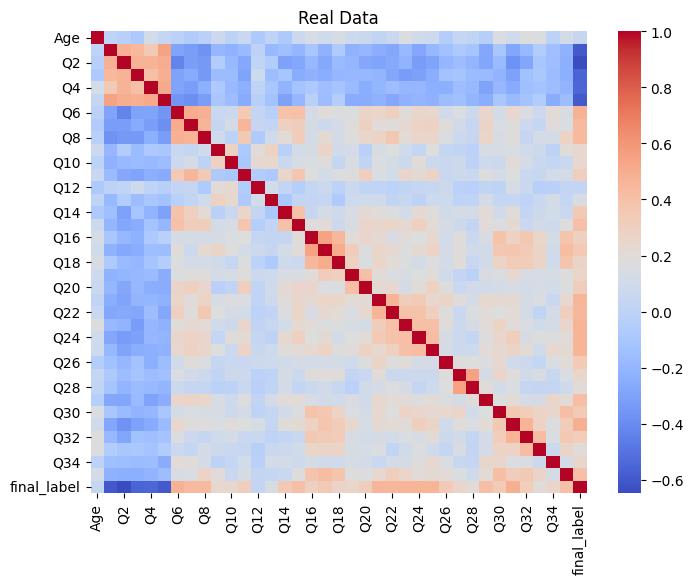

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Real Data")
plt.show()

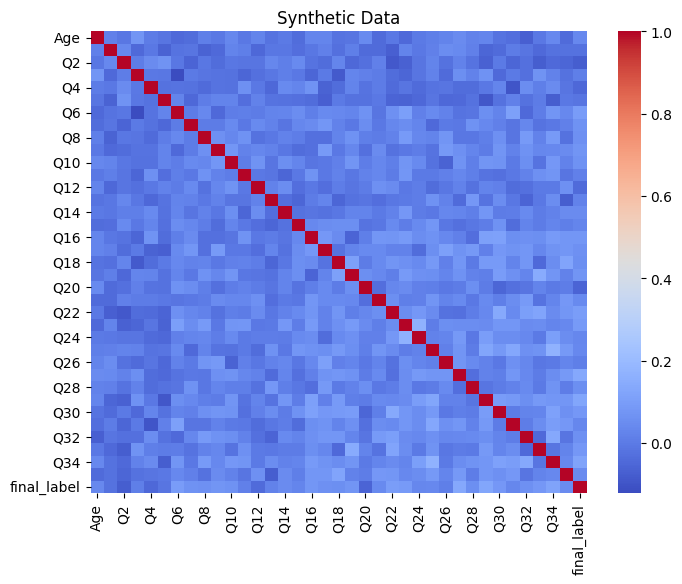

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(synthetic_df.corr(), cmap="coolwarm")
plt.title("Synthetic Data")
plt.show()

In [22]:
real_labels = np.zeros(len(df))
synthetic_labels = np.ones(len(synthetic_df))

X_combined = np.vstack([df.values, synthetic_df.values])
y_combined = np.hstack([real_labels, synthetic_labels])

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, test_size=0.3
)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classifier Accuracy:", accuracy_score(y_test, y_pred))

Classifier Accuracy: 0.8505747126436781
